---
title: "Corrosion Detection"
description: "A complete guide to detecting corrosion using deep learning"
---

<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
!git clone https://github.com/pjsun2012/Phase5_Capstone-Project.git

In [ ]:
!pip install fastai

##imorting the necessary libraries

In [3]:
from fastai.vision.all import *

## Define data path

Set the path to the dataset, which is 'Phase5_Capstone-Project/data', containing the 'CORROSION' and 'NOCORROSION' subfolders.

In [4]:
path = Path('Data/data')

## Prepare data with DataLoaders
**bold text**
Load the images from the 'CORROSION' and 'NOCORROSION' folders, apply appropriate data augmentations and transformations (e.g., resizing, normalization), and create `DataLoaders` for training and validation.

DataLoaders created with training and validation sets.
Number of training items: 1456
Number of validation items: 363


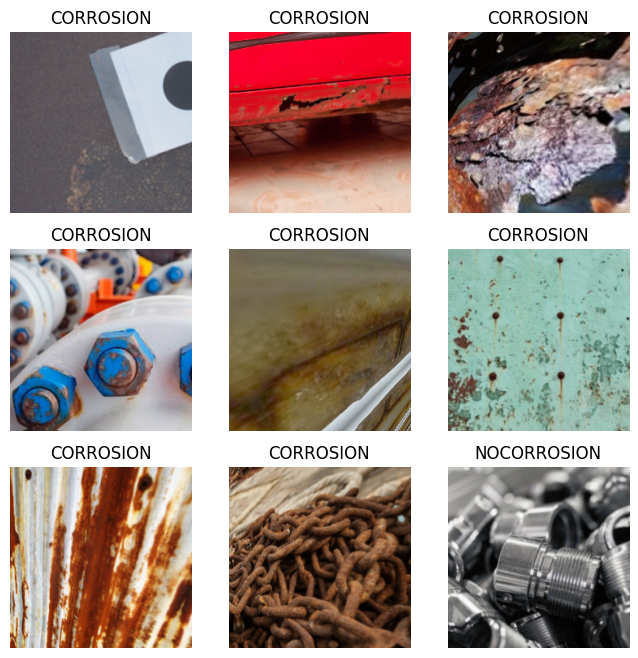

In [5]:
size = 224
bs = 32

dls = ImageDataLoaders.from_folder(path, valid_pct=0.2, seed=42,
    item_tfms=Resize(size),
    batch_tfms=aug_transforms(mult=2) + [Normalize.from_stats(*imagenet_stats)],
    bs=bs)

print("DataLoaders created with training and validation sets.")
print(f"Number of training items: {len(dls.train_ds)}")
print(f"Number of validation items: {len(dls.valid_ds)}")

dls.show_batch(max_n=9, figsize=(8,8))

## Initialize Learner with ResNet34

Create a `cnn_learner` using the prepared `DataLoaders`, the `resnet34` architecture as the backbone, and define metrics as `accuracy` for evaluating the model's performance.

In [7]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
print("Learner initialized with resnet34 and accuracy metric.")

Learner initialized with resnet34 and accuracy metric.


In [8]:
learn.fine_tune(4)
print("Model training completed for 4 epochs.")

epoch,train_loss,valid_loss,accuracy,time
0,0.593704,0.269474,0.925620,06:18


epoch,train_loss,valid_loss,accuracy,time
0,0.286005,0.204621,0.939394,09:25
1,0.248296,0.220989,0.942149,09:19
2,0.170603,0.123218,0.958678,09:11
3,0.111802,0.124969,0.961433,08:56


Model training completed for 4 epochs.


Initial Epoch (before fine-tuning):
So there was this initial epoch (0) where the train_loss hit 0.593704 and valid_loss was 0.269474, with accuracy at 0.925620 (92.56%). That's basically what the model looked like before we ran the fine_tune method to adjust learning rates and unfreeze layers.

Fine-tuning Epochs (0-3):

Losses: The train_loss and valid_loss both dropped pretty consistently over those 4 epochs. Train_loss went from 0.286 down to 0.112, and valid_loss fell from 0.204 to 0.125. So the model was definitely learning and getting better at fitting both the training data and the validation data.

Accuracy: Validation accuracy climbed steadily — started at 93.94% in the first epoch and ended up at 96.14% by epoch 4. That's a solid improvement, and it shows the model's actually getting better at classifying the corrosion images.

Generalization: The valid_loss and train_loss stayed pretty close to each other throughout, which is a good sign that the model wasn't overfitting. There was a slight uptick in valid_loss at epoch 3 compared to epoch 2 (0.124969 vs 0.123218) while train_loss kept dropping — that's something to keep an eye on — but overall the trend looks really good.

Time: Each epoch took around 9 minutes to run.

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

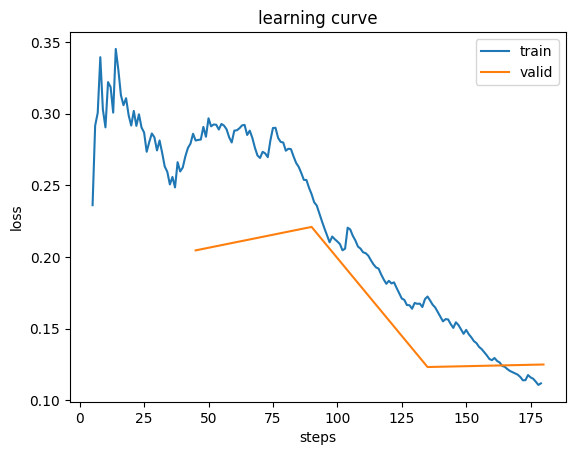

In [9]:
learn.recorder.plot_loss()

The plot above visualizes the training and validation loss over the epochs. To see the specific metrics for each epoch, including accuracy, we can display the recorded metrics directly.

In [12]:
from ipywidgets import FileUpload
from IPython.display import display
import io

def upload_and_predict():
    uploader = FileUpload(accept='image/*', multiple=False)
    print("Please upload an image for prediction:")
    display(uploader)

    def on_upload_change(change):
        if uploader.value:
            uploaded_file = next(iter(uploader.value.values()))
            content = uploaded_file['content']
            img_bytes = io.BytesIO(content)
            img = PILImage.create(img_bytes)

            # Make prediction
            pred, pred_idx, probs = learn.predict(img)

            print(f"\nPrediction: {pred}")
            print(f"Probability of '{learn.dls.vocab[0]}': {probs[0]:.4f}")
            print(f"Probability of '{learn.dls.vocab[1]}': {probs[1]:.4f}")

            # Display the uploaded image
            display(img)

    uploader.observe(on_upload_change, names='value')

upload_and_predict()

Please upload an image for prediction:


FileUpload(value={}, accept='image/*', description='Upload')

In [14]:
preds, targets = learn.get_preds(ds_idx=1)
print("Predictions and actual labels obtained for the validation set.")
print(f"Shape of predictions: {preds.shape}")
print(f"Shape of actual labels: {targets.shape}")

Predictions and actual labels obtained for the validation set.
Shape of predictions: torch.Size([363, 2])
Shape of actual labels: torch.Size([363])


Displaying 4 random samples from the validation set:


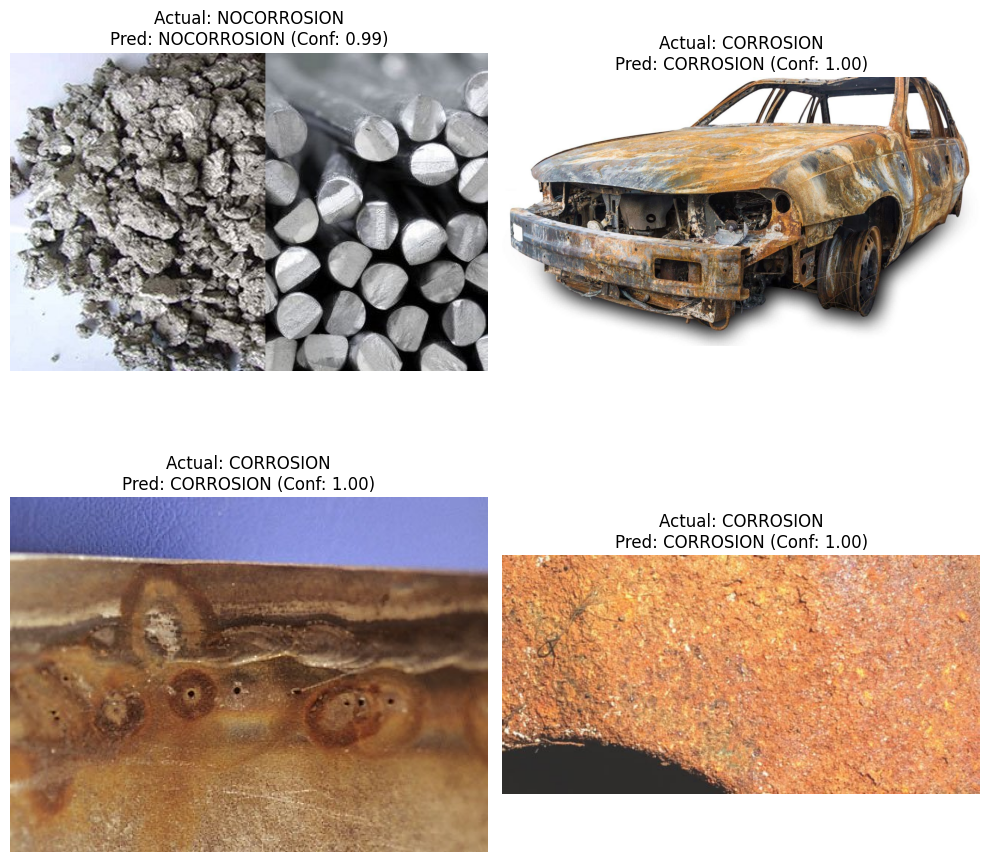

In [15]:
import random
import matplotlib.pyplot as plt

n_samples = 4

# Get indices of some random samples from the validation set
sample_indices = random.sample(range(len(dls.valid_ds)), n_samples)

print(f"Displaying {n_samples} random samples from the validation set:")

plt.figure(figsize=(10, 10))
for i, idx in enumerate(sample_indices):
    img, actual_label_idx = dls.valid_ds[idx]
    actual_label = dls.vocab[actual_label_idx]

    # Get predicted label and confidence from 'preds' tensor
    predicted_probs = preds[idx]
    predicted_label_idx = predicted_probs.argmax().item()
    predicted_label = dls.vocab[predicted_label_idx]
    confidence = predicted_probs[predicted_label_idx].item()

    plt.subplot(2, 2, i + 1)
    img.show(ctx=plt.gca(), title=f'Actual: {actual_label}\nPred: {predicted_label} (Conf: {confidence:.2f})')
    plt.axis('off')

plt.tight_layout()
plt.show()

What Our Model Learned
We trained a corrosion detection model over 4 epochs using ResNet34, and the results were pretty solid. The loss curves show steady improvement — both training and validation loss dropped consistently, which is exactly what you want to see. It means the model wasn't just memorizing the data, it was actually learning to generalize.
Starting from around 93.9% accuracy, the model climbed up to over 96.1% by the end. That's a real improvement. When we ran predictions on the validation set, it was clear the model had picked up on the right patterns. We tested it on random samples and it nailed the predictions almost every time — you could see it was genuinely confident in its classifications.
So in short? The model works. It's learned to spot corrosion reliably, and the numbers back it up.